# Tic Tac Toe with Competing Agents

## Scenario

This experiment is distinct from the previous 'competing drive' notebooks.

This time I wanted to attempt to get an agent to play a game of Tic Tac Toe without any explicitly encoded rules, purely through preference alignment.

Furthermore, I wanted it to play against a copy of itself.

Being a game of perfect information this seemed like a reasonable challenge, with a view towards modelling partial information games like poker in the future.

I was successful, with some caveats:
1. It works perfectly on a 3 * 3 grid. Moving to 4*4 I see some non-optimal moves but I think that parameter tuning could fix this.
2. It takes a couple of seconds to run a full 3 * 3 grid game, but a 4 * 4 takes 5 minutes **per move** due to moving from 3^9 to 3^16 possible cell state combinations.

Parameter tuning is slow because I have to use a 4 * 4 grid to evaluate changes. If I can speed up the inference, I can experiment with different settings quickly.

In the next notebook I plan to explore the JAX version of pymdp to see if it is faster.

In [23]:
%pip install inferactively-pymdp

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pymdp.agent import Agent
from pymdp import utils
from copy import deepcopy

## Hidden States

We will begin by defining a few constants to make the following code easier to read.

Each cell can be one of Empty, O, or X.

It is either Player O's or Player X's turn.

We also track the empty count, or 'moves left' as a distinct cell state.

> We could infer an observation of empty count from the cell states, but we need it in the state itself because in this implementation it is used for the B matrix transition during the opponent's turn to calculate the chance of the remaining cells being taken. More info in the B section below.

In [25]:
grid_size = 3
win_length = 3  # e.g. 3 for classic tic tac toe
n_cells = grid_size * grid_size

# Empty Count options (0 to n_cells inclusive,so 17 vals for 16 cells)
empty_count_states = list(range(0, n_cells + 1))

CELL_EMPTY = 0
CELL_O = 1
CELL_X = 2
n_cell_states = 3
cell_labels = ["Empty", "O", "X"]

PLAYER_O = 0
PLAYER_X = 1
n_turn_states = 2  # O's turn, X's turn

ACTION_STAY = 0
ACTION_MARK = 1
n_empty_count_states = len(empty_count_states)

n_states = [n_cell_states] * n_cells + [n_turn_states] + [n_empty_count_states]

print(f"Number of states\n{n_cell_states} cell states * {n_cells} cells, 2 turn states, {n_empty_count_states} empty states:\n{n_states}")

Number of states
3 cell states * 9 cells, 2 turn states, 10 empty states:
[3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 10]


## A Matrix: Observation -> State

The agent makes confident observations of each hidden state factor (cells, turn and empty count).

The solution I have come up with also *infers* an observation of each possible cell combination of minimum `win_length`, which I will refer to as 'chunks'.

Chunks can be observed to be
- Empty
- Unwinnable (a mix of players)
- O-in-n (number of moves until O wins, from 0 (won) to win_lenth-1 (one cell taken))
- X-in-n (as above)

Later on we will see how the agent's preferences are represented in terms of observed chunks.

In [26]:
chunk_obs_labels = ['Empty', 'Unwinnable'] + [f'OIn{i}' for i in range(0, win_length)] + [f'XIn{i}' for i in range(0, win_length)]

def get_chunks(grid_size, win_length):
    """Return a list of lists, each sublist is indices of a winning line."""
    chunks = []
    # Rows
    for r in range(grid_size):
        for c in range(grid_size - win_length + 1):
            chunks.append([r * grid_size + c + i for i in range(win_length)])
    # Columns
    for c in range(grid_size):
        for r in range(grid_size - win_length + 1):
            chunks.append([(r + i) * grid_size + c for i in range(win_length)])
    # Diagonals
    for r in range(grid_size - win_length + 1):
        for c in range(grid_size - win_length + 1):
            # Down-right
            chunks.append([(r + i) * grid_size + (c + i) for i in range(win_length)])
            # Down-left
            chunks.append([(r + i) * grid_size + (c + win_length - 1 - i) for i in range(win_length)])
    return chunks

chunks = get_chunks(grid_size, win_length)
n_chunks = len(chunks)

cell_obs = [ 3 for _ in range(n_cells) ]
chunk_obs = [ len(chunk_obs_labels) for _ in range(n_chunks) ]
n_obs = [*cell_obs, 2, len(empty_count_states), *chunk_obs]

print("Chunk labels:", chunk_obs_labels)
print(f"Number of Chunks: {n_chunks}")
print(f"Chunk cell indices: {chunks}")
print(f"Observation Dimensionalities: {n_obs}")

Chunk labels: ['Empty', 'Unwinnable', 'OIn0', 'OIn1', 'OIn2', 'XIn0', 'XIn1', 'XIn2']
Number of Chunks: 8
Chunk cell indices: [[0, 1, 2], [3, 4, 5], [6, 7, 8], [0, 3, 6], [1, 4, 7], [2, 5, 8], [0, 4, 8], [2, 4, 6]]
Observation Dimensionalities: [3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 10, 8, 8, 8, 8, 8, 8, 8, 8]


In order to attempt to fight the impending combinatorial explosion, this time around I have restricted the A matrix mappings to only depend on the factors which affect them, just as we have done with the B matrix previously.

- Each cell observation depends only on the hidden state of the cell it represents.
- The turn and empty count observations also only depend on the matching hidden states.
- The chunk observations each depend only on the cells which define them. For example with win length 3, chunk 1 would depend on cells 0, 1 and 2.

In [27]:
A_factor_list = []

for i in range(n_cells):
    A_factor_list.append([i])  # cell obs depend on cell state

A_factor_list.append([n_cells])  # turn obs depends on turn state
A_factor_list.append([n_cells+1])  # empty count obs depends on empty count state

for i, chunk in enumerate(chunks): # chunks depend on the cells they observe
    A_factor_list.append(chunk)

print(f"A dependencies: {A_factor_list}")

A dependencies: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [0, 1, 2], [3, 4, 5], [6, 7, 8], [0, 3, 6], [1, 4, 7], [2, 5, 8], [0, 4, 8], [2, 4, 6]]


We'll initialise the A matrix with zeroes. It has one state for each cell obs, turn obs, and empty count obs plus win_length states for each chunk obs

In [28]:
A = utils.obj_array(len(n_obs))
for i in range(len(n_obs)):
    A[i] = np.zeros((n_obs[i],) + tuple([n_states[j] for j in A_factor_list[i]]))

# For each modality, its observation count followed by the counts of every hidden state it depends on.
for i in range(len(n_obs)):
    print(f"A[{i}] shape: {A[i].shape}")

A[0] shape: (3, 3)
A[1] shape: (3, 3)
A[2] shape: (3, 3)
A[3] shape: (3, 3)
A[4] shape: (3, 3)
A[5] shape: (3, 3)
A[6] shape: (3, 3)
A[7] shape: (3, 3)
A[8] shape: (3, 3)
A[9] shape: (2, 2)
A[10] shape: (10, 10)
A[11] shape: (8, 3, 3, 3)
A[12] shape: (8, 3, 3, 3)
A[13] shape: (8, 3, 3, 3)
A[14] shape: (8, 3, 3, 3)
A[15] shape: (8, 3, 3, 3)
A[16] shape: (8, 3, 3, 3)
A[17] shape: (8, 3, 3, 3)
A[18] shape: (8, 3, 3, 3)


We need a function which can convert a list of cell states into a chunk observation

In [29]:
def get_chunk_obs(chunk_cell_states):
    n_empty = sum([s == CELL_EMPTY for s in chunk_cell_states])
    n_O = sum([s == CELL_O for s in chunk_cell_states])
    n_X = sum([s == CELL_X for s in chunk_cell_states])
    if n_empty == len(chunk_cell_states):
        return chunk_obs_labels.index('Empty')
    if n_O > 0 and n_X > 0:
        return chunk_obs_labels.index('Unwinnable')
    if n_X == 0:
        return chunk_obs_labels.index('OIn1') + n_empty - 1
    if n_O == 0:
        return chunk_obs_labels.index('XIn1') + n_empty - 1
    raise ValueError("Invalid chunk state")

In [30]:
# Cell observations - identity
for i in range(n_cells):
    for state in range(3):
        A[i][state, state] = 1.

# Turn observation - identity
turn_idx = n_cells
for state in range(2):
    A[turn_idx][state, state] = 1.0

# Empty count observation - identity
empty_count_idx = n_cells + 1
for state in range(n_empty_count_states):
    A[empty_count_idx][state, state] = 1.0

# Chunk observations.
chunk_start_idx = n_cells + 2
for i, chunk in enumerate(chunks):
    for cell_states in np.ndindex((3,) * win_length):
        obs = get_chunk_obs(cell_states)
        print(f"Chunk {i} {list(map(lambda c: cell_labels[c], cell_states))} is {chunk_obs_labels[obs]}")
        A[chunk_start_idx + i][obs, *cell_states] = 1.0

Chunk 0 ['Empty', 'Empty', 'Empty'] is Empty
Chunk 0 ['Empty', 'Empty', 'O'] is OIn2
Chunk 0 ['Empty', 'Empty', 'X'] is XIn2
Chunk 0 ['Empty', 'O', 'Empty'] is OIn2
Chunk 0 ['Empty', 'O', 'O'] is OIn1
Chunk 0 ['Empty', 'O', 'X'] is Unwinnable
Chunk 0 ['Empty', 'X', 'Empty'] is XIn2
Chunk 0 ['Empty', 'X', 'O'] is Unwinnable
Chunk 0 ['Empty', 'X', 'X'] is XIn1
Chunk 0 ['O', 'Empty', 'Empty'] is OIn2
Chunk 0 ['O', 'Empty', 'O'] is OIn1
Chunk 0 ['O', 'Empty', 'X'] is Unwinnable
Chunk 0 ['O', 'O', 'Empty'] is OIn1
Chunk 0 ['O', 'O', 'O'] is OIn0
Chunk 0 ['O', 'O', 'X'] is Unwinnable
Chunk 0 ['O', 'X', 'Empty'] is Unwinnable
Chunk 0 ['O', 'X', 'O'] is Unwinnable
Chunk 0 ['O', 'X', 'X'] is Unwinnable
Chunk 0 ['X', 'Empty', 'Empty'] is XIn2
Chunk 0 ['X', 'Empty', 'O'] is Unwinnable
Chunk 0 ['X', 'Empty', 'X'] is XIn1
Chunk 0 ['X', 'O', 'Empty'] is Unwinnable
Chunk 0 ['X', 'O', 'O'] is Unwinnable
Chunk 0 ['X', 'O', 'X'] is Unwinnable
Chunk 0 ['X', 'X', 'Empty'] is XIn1
Chunk 0 ['X', 'X', 'O'] i

### Normalisation

The probabilities of possible observations given a state must sum to 1.

In [31]:
all_normalized = True
for m in range(len(A)):
    # Sum over observation dimension (axis 0) should be 1 for all state configs
    sum_over_obs = A[m].sum(axis=0)
    is_norm_m = np.allclose(sum_over_obs, 1.0)
    if not is_norm_m:
        print(f"Warning: A[{m}] is NOT normalized!")
        all_normalized = False

print(f"All A sub-arrays are normalized: {all_normalized}")

All A sub-arrays are normalized: True


## B Matrix: State -> Action -> State

The B matrix obviously doesn't consider the chunks, since they are observations inferred from the state prior and B only deals with the state prior itself (cells, turn and empty count).

- Each cell has two actions, 'Do nothing' (Stay) or 'Mark'.
- The turn and empty count aren't user controllable so only have their singular default action.

### Dependencies

To understand  the dependencies, it's worth explaining the way the opponent is modelled in this two player game.

I considered three options:

1. Don't model them. Assume I am the only actor in the environment and be shocked every time the board comes back with an unexpected mark.

2. Model them as a random actor. Assume that on their turn, every empty cell has an even chance of being marked.

3. Model them as a rational actor, i.e. *what would I do if I was them, with the info they have?* Given in this case we have the same info, this is essentially 'what would I do if it were my turn and the signs were flipped'.

The first option isn't very appealing as it isn't how a game is played in the real world.

The third option, modelling the opponent, sounds fascinating and plausible. It becomes a model of game theory, and could recurse ('given what I know they know I know they know etc etc).

However, pragmatically it also sounds more complex than the random actor, so I decided to take that approach first.

This is why, as previously mentioned, we need the empty count explicitly encoded in the state model rather than inferred as an observation.


In [43]:
n_controls = [2] * n_cells + [1, 1] # 2 actions for each cell: Stay or Mark. Null action for turn and empty count.
control_fac_idx = list(range(n_cells))  # only cell states are controllable

B_factor_list = []
for i in range(n_cells):
    B_factor_list.append([turn_idx, empty_count_idx, i])  # cell transitions depend on cell state, turn, empty count
B_factor_list.append([turn_idx])  # turn transition depends on turn state
B_factor_list.append([empty_count_idx])  # empty count transition depends on empty count state

print(f"Actions: {n_controls}")
print(f"Controllable items: {control_fac_idx}")
print(f"B dependencies: {B_factor_list}")

Actions: [2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1]
Controllable items: [0, 1, 2, 3, 4, 5, 6, 7, 8]
B dependencies: [[9, 10, 0], [9, 10, 1], [9, 10, 2], [9, 10, 3], [9, 10, 4], [9, 10, 5], [9, 10, 6], [9, 10, 7], [9, 10, 8], [9], [10]]


The B matrix transition depends on whose turn it is, so we need one for O and one for X.

> I tried modelling it as 'MyTurn' and 'TheirTurn' which allowed a single B and C matrix but required two A matrices and worse, two observations with the turn state inverted. With this approach there is one true observation and one set of chunks which the agents interpret based on their preference for O or X winning, which feels more real-world.

- If it is your turn, you are allowed to mark **one** cell.
- If it is the opponent's turn, each empty cell has `1/empty_count` chance of being marked by your opponent.

In [33]:
B4O = utils.obj_array(len(n_states))
B4X = utils.obj_array(len(n_states))
for i in range(n_cells):
    B4O[i] = np.zeros((n_cell_states, n_turn_states, n_empty_count_states, n_cell_states, 2))
    B4X[i] = np.zeros((n_cell_states, n_turn_states, n_empty_count_states, n_cell_states, 2))
    for prev in range(n_cell_states):
        for turn in range(n_turn_states):
            for emptyCount in range(n_empty_count_states):
                for act in range(2):  # Stay, Mark
                    if turn == PLAYER_O:
                        if act == ACTION_MARK and prev == CELL_EMPTY:
                            B4O[i][CELL_O, turn, emptyCount, prev, act] = 1.0 # If marking an empty cell, it becomes O
                        else:
                            B4O[i][prev, turn, emptyCount, prev,  act] = 1.0 # Otherwise unchanged
                        if prev == CELL_EMPTY:
                            if emptyCount > 1: # If you are empty and not the only one you have a chance of being taken by O or remaining empty
                                B4X[i][CELL_X, turn, emptyCount, prev, act] = 1.0 / emptyCount
                                B4X[i][CELL_EMPTY, turn, emptyCount, prev, act] = (emptyCount - 1) / emptyCount
                            else: # You must be the only empty cell so will be taken by O
                                B4X[i][CELL_X, turn, emptyCount, prev, act] = 1.0
                        else:
                            B4X[i][prev, turn, emptyCount, prev, act] = 1.0 # If not empty, unchanged
                    else: # turn == PLAYER_X
                        if act == ACTION_MARK and prev == CELL_EMPTY:
                            B4X[i][CELL_X, turn, emptyCount, prev, act] = 1.0 # If marking an empty cell, it becomes X
                        else:
                            B4X[i][prev, turn, emptyCount, prev,  act] = 1.0 # Otherwise unchanged
                        if prev == CELL_EMPTY:
                            if emptyCount > 1: # If you are empty and not the only one you have a chance of being taken by O or remaining empty
                                B4O[i][CELL_O, turn, emptyCount, prev, act] = 1.0 / emptyCount
                                B4O[i][CELL_EMPTY, turn, emptyCount, prev, act] = (emptyCount - 1) / emptyCount
                            else: # You must be the only empty cell so will be taken by O
                                B4O[i][CELL_O, turn, emptyCount, prev, act] = 1.0
                        else:
                            B4O[i][prev, turn, emptyCount, prev, act] = 1.0 # If not empty, unchanged


# Turn transitions
B4O[turn_idx] = np.zeros((n_turn_states, n_turn_states, 1))
B4X[turn_idx] = np.zeros((n_turn_states, n_turn_states, 1))
for s in range(n_turn_states):
    for prev in range(n_turn_states):
        B4O[turn_idx][s, prev, 0] = 1.0 if s == 1-prev else 0.0
        B4X[turn_idx][s, prev, 0] = 1.0 if s == 1-prev else 0.0

# Empty count transitions
B4O[empty_count_idx] = np.zeros((n_empty_count_states,  n_empty_count_states, 1))
B4X[empty_count_idx] = np.zeros((n_empty_count_states,  n_empty_count_states, 1))
for s in range(n_empty_count_states):
    for prev in range(n_empty_count_states):
        B4O[empty_count_idx][max(0, s-1), s, 0] = 1.0
        B4X[empty_count_idx][max(0, s-1), s, 0] = 1.0

for i in range(len(B4O)):
    print(f"B4O[{i}] shape: {B4O[i].shape}")

B4O[0] shape: (3, 2, 10, 3, 2)
B4O[1] shape: (3, 2, 10, 3, 2)
B4O[2] shape: (3, 2, 10, 3, 2)
B4O[3] shape: (3, 2, 10, 3, 2)
B4O[4] shape: (3, 2, 10, 3, 2)
B4O[5] shape: (3, 2, 10, 3, 2)
B4O[6] shape: (3, 2, 10, 3, 2)
B4O[7] shape: (3, 2, 10, 3, 2)
B4O[8] shape: (3, 2, 10, 3, 2)
B4O[9] shape: (2, 2, 1)
B4O[10] shape: (10, 10, 1)


### Normalisation

Your beliefs about your resulting state given a starting state and an action must sum to 1.

In [34]:
for f in range(len(B4O)):
    B_f = B4O[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"Warning: BO[{f}] column at {idx} sums to {col_sum:.3f}") 

In [35]:
for f in range(len(B4X)):
    B_f = B4X[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"Warning: BX[{f}] column at {idx} sums to {col_sum:.3f}")    

### Policies

We want to say 'mark only **one** cell', but by default the agent would choose an action for every cell. Presumably it would just mark the entire board with its sign on turn one. An effective strategy but not what we're after.

The way to achieve this is to pass a `policies` list to the `Agent` constructor, artificially limiting its policy search space to those you provide.

We can use a pymdp utility to get the collection of *all* policies, then filter to only those where a single cell is marked.

In [36]:
from pymdp.control import construct_policies  
import numpy as np  
  
policy_len = 1
all_policies = construct_policies(n_states, n_controls, policy_len=policy_len)  
  
# Keep policies where exactly one controllable factor changes per timestep  
policies = [  
    p for p in all_policies
    if all(np.count_nonzero(p[t, control_fac_idx]) == 1 for t in range(policy_len))  
]

print(f"Generated {len(policies)} policies:")
for i, pol in enumerate(policies):
    print(f"Policy {i}: {pol}")

Generated 9 policies:
Policy 0: [[0 0 0 0 0 0 0 0 1 0 0]]
Policy 1: [[0 0 0 0 0 0 0 1 0 0 0]]
Policy 2: [[0 0 0 0 0 0 1 0 0 0 0]]
Policy 3: [[0 0 0 0 0 1 0 0 0 0 0]]
Policy 4: [[0 0 0 0 1 0 0 0 0 0 0]]
Policy 5: [[0 0 0 1 0 0 0 0 0 0 0]]
Policy 6: [[0 0 1 0 0 0 0 0 0 0 0]]
Policy 7: [[0 1 0 0 0 0 0 0 0 0 0]]
Policy 8: [[1 0 0 0 0 0 0 0 0 0 0]]


## C Matrix: Preferred State

The C matrix is pretty simple.

The agents only care about the chunk observations, and they favour chunks that have them winning. 

The closer a chunk is to them winning, the more they like it.

The closer a chunk is to losing, the more they hate it.

These are almost balanced with the desire to win slightly stronger than the desire to stop the opponent winning to encourage taking a win over blocking if possible.

> As mentioned at the top, when moving to a (currently very slow, 5 min per turn) 4 * 4 grid I don't always see optimal behaviour, so clearly some of my scaling parameters or assumptions about the effects of C are incorrect.

In [37]:
C4O = utils.obj_array_zeros(n_obs)
C4X = utils.obj_array_zeros(n_obs)

# Cell obs: neutral
for i in range(n_cells):
    C4O[i] = np.zeros(n_cell_states)
    C4X[i] = np.zeros(n_cell_states)

# Turn obs: neutral
C4O[turn_idx] = np.zeros(n_turn_states)
C4X[turn_idx] = np.zeros(n_turn_states)

# Empty count obs: neutral
C4O[empty_count_idx] = np.zeros(n_empty_count_states)
C4X[empty_count_idx] = np.zeros(n_empty_count_states)

# Chunk obs: increasingly positive for win, increasingly negative for lose.
# Win beats lose if equal distance.
# Don't care about unwinnable or empty.
for i in range(n_chunks):
    c_vec_o = np.zeros(len(chunk_obs_labels))
    c_vec_x = np.zeros(len(chunk_obs_labels))
    for j, label in enumerate(chunk_obs_labels):
        if label.startswith('OIn'):
            o_distance = int(label[len('OIn'):])
            o_score = win_length - o_distance  # Higher score for smaller distance to win
            # if o_distance > 0:
            c_vec_o[j] = (o_score ** 2) # O reward for O gaining
            c_vec_x[j] = -(o_score ** 2) * 0.9 # X penalty for O gaining
            # else:
            #     c_vec_o[j] = 50.0 # O reward for win (slightly higher than penalty for losing to ensure winning is preferred)
            #     c_vec_x[j] = -45.0  # X penalty for loss
        elif label.startswith('XIn'):
            x_distance = int(label[len('XIn'):])
            x_score = win_length - x_distance  # Higher score for smaller distance to win
            # if x_distance > 0:
            c_vec_x[j] = (x_score ** 2) # X reward for X gaining
            c_vec_o[j] = -(x_score ** 2) * 0.9 # O penalty for X gaining
            # else:
            #     c_vec_x[j] = 50.0  # X reward for win (slightly higher than penalty for losing to ensure winning is preferred)
            #     c_vec_o[j] = -45.0  # O penalty for loss
    C4O[chunk_start_idx+i] = c_vec_o
    C4X[chunk_start_idx+i] = c_vec_x

for i in range(len(C4O)):
    print(f"C4O[{i}] shape: {C4O[i].shape}")

print(f"Chunk obs C4O[{chunk_start_idx}] values: {C4O[chunk_start_idx]}")
print(f"Chunk obs C4X[{chunk_start_idx}] values: {C4X[chunk_start_idx]}")

C4O[0] shape: (3,)
C4O[1] shape: (3,)
C4O[2] shape: (3,)
C4O[3] shape: (3,)
C4O[4] shape: (3,)
C4O[5] shape: (3,)
C4O[6] shape: (3,)
C4O[7] shape: (3,)
C4O[8] shape: (3,)
C4O[9] shape: (2,)
C4O[10] shape: (10,)
C4O[11] shape: (8,)
C4O[12] shape: (8,)
C4O[13] shape: (8,)
C4O[14] shape: (8,)
C4O[15] shape: (8,)
C4O[16] shape: (8,)
C4O[17] shape: (8,)
C4O[18] shape: (8,)
Chunk obs C4O[11] values: [ 0.   0.   9.   4.   1.  -8.1 -3.6 -0.9]
Chunk obs C4X[11] values: [ 0.   0.  -8.1 -3.6 -0.9  9.   4.   1. ]


## D Matrix : Starting State Belief

The starting state belief depends on whether you go first or not.

If so, you expect the board to be empty.

If not you expect one of the cells to be marked but you don't know which, all have even probability (1/cell count).

In [38]:
def getDForPlayer(startingPlayer, player):
    D = utils.obj_array(len(n_states))
    # Cell states
    for i in range(n_cells):
        d = np.zeros(n_cell_states)
        if startingPlayer == player:
            d[CELL_EMPTY] = 1.0 # All empty
        else:            
            d[CELL_EMPTY] = (n_cells - 1) / n_cells  # Most empty
            if player == PLAYER_O:
                d[CELL_X] = 1.0 / n_cells  # One will be marked by opponent
            else: 
                d[CELL_O] = 1.0 / n_cells
        D[i] = d

    # Turn state
    turn_d = np.zeros(n_turn_states)
    turn_d[startingPlayer] = 1.0
    D[n_cells] = turn_d

    # Empty count state
    empty_d = np.zeros(n_empty_count_states)
    empty_d[-1] = 1.0  # start with all cells empty (index n_cells - 1)
    D[n_cells+1] = empty_d
    return D

startingPlayer = PLAYER_O
D4O = getDForPlayer(startingPlayer=startingPlayer, player=PLAYER_O)
D4X = getDForPlayer(startingPlayer=startingPlayer, player=PLAYER_X)

print("D matrices initialized for factorized state space:")
for i in range(len(D4O)):
    print(f"D4O[{i}] shape: {D4O[i].shape}")
    print(f"State prior {i}: {D4O[i]}")
for i in range(len(D4X)):
    print(f"D4X[{i}] shape: {D4X[i].shape}")
    print(f"State prior {i}: {D4X[i]}")

D matrices initialized for factorized state space:
D4O[0] shape: (3,)
State prior 0: [1. 0. 0.]
D4O[1] shape: (3,)
State prior 1: [1. 0. 0.]
D4O[2] shape: (3,)
State prior 2: [1. 0. 0.]
D4O[3] shape: (3,)
State prior 3: [1. 0. 0.]
D4O[4] shape: (3,)
State prior 4: [1. 0. 0.]
D4O[5] shape: (3,)
State prior 5: [1. 0. 0.]
D4O[6] shape: (3,)
State prior 6: [1. 0. 0.]
D4O[7] shape: (3,)
State prior 7: [1. 0. 0.]
D4O[8] shape: (3,)
State prior 8: [1. 0. 0.]
D4O[9] shape: (2,)
State prior 9: [1. 0.]
D4O[10] shape: (10,)
State prior 10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
D4X[0] shape: (3,)
State prior 0: [0.88888889 0.11111111 0.        ]
D4X[1] shape: (3,)
State prior 1: [0.88888889 0.11111111 0.        ]
D4X[2] shape: (3,)
State prior 2: [0.88888889 0.11111111 0.        ]
D4X[3] shape: (3,)
State prior 3: [0.88888889 0.11111111 0.        ]
D4X[4] shape: (3,)
State prior 4: [0.88888889 0.11111111 0.        ]
D4X[5] shape: (3,)
State prior 5: [0.88888889 0.11111111 0.        ]
D4X[6] shape: (3,)


### Normalisation

As usual the sum of beliefs has to equal 1.

In [39]:
for f in range(len(D4X)):
    D_f = D4X[f]
    total = D_f.sum()
    if not np.isclose(total, 1.0):
        print(f"Warning: D[{f}] sums to {total:.3f}")

## Generative Process: The Environment

The environment is super simple, it just tracks the marked cells, the turn and the empty count.

We only pass in the action from the agent whose turn it is, but if we did pass in the other agent's action it would be ignored.

In [40]:
# --- Environment Implementation ---
class TicTacToeEnv:
    def __init__(self, grid_size, win_length):
        self.grid_size = grid_size
        self.n_cells = grid_size * grid_size
        self.win_length = win_length
        self.chunks = get_chunks(grid_size, win_length)
        self.reset()

    def reset(self):
        self.cells = [0] * self.n_cells  # all empty
        self.turn = PLAYER_O
        self.empty_count = self.n_cells
        self.done = False
        return self._get_obs()

    def _get_obs(self):
        obs_cells = deepcopy(self.cells)
        obs_chunks = []
        for chunk in self.chunks:
            chunk_states = [self.cells[i] for i in chunk]
            obs_chunks.append(get_chunk_obs(chunk_states))
        return tuple(obs_cells) + (self.turn,) + (self.empty_count,) + tuple(obs_chunks)

    def step(self, action, agent):
        # action: index of cell to mark
        if self.done:
            return self._get_obs(), 0, True
        
        if self.turn == agent: # Don't allow the agent to play for the opponent
            if self.cells[action] == CELL_EMPTY:
                self.cells[action] = CELL_O if agent == PLAYER_O else CELL_X
                self.empty_count -= 1
            # Check for win/draw
            winner = self._check_winner()
            if winner is not None or self.empty_count == 0:
                self.done = True
                return self._get_obs(), winner, True
            # Switch turn
            self.turn = 1 - self.turn
           
        return self._get_obs(), 0, False

    def _check_winner(self):
        for chunk in self.chunks:
            vals = [self.cells[i] for i in chunk]
            if all(v == CELL_O for v in vals):
                return 1  # O wins
            if all(v == CELL_X for v in vals):
                return -1  # X wins
        return None


### Sampling mode and action selection

When I first ran the complete solution it wasn't working at all, and I finally traced the bug to the policy selection. Depite the fact I had filtered to only policies where one cell changes, it was choosing to mark zero cells. How could this be?

It turned out to be the way the final action is derived from policies by default.

The first action of each policy is weighted by the likelyhood of that policy (its marginal).

The marginals are normalised and then each action is sampled from that distribution individually. If the distribution is uniform, they are all equally likely and so zero is chosen. This way we end up with an all zero action sample even though none of the policies explicitly contained that combination of actions.

A solution to this was to switch from `sampling_mode=marginal` (the default) to `sampling_mode=full`. This will sample a single policy and pick the first action in its entirety, ensuring we only get a sample that is in the allowed policy list.

In [41]:
agent_O = Agent(A=A, B=B4O, C=C4O, D=D4O, sampling_mode="full", policies=policies, policy_len=policy_len, A_factor_list=A_factor_list, B_factor_list=B_factor_list, control_fac_idx=control_fac_idx)
agent_X = Agent(A=A, B=B4X, C=C4X, D=D4X, sampling_mode="full", policies=policies, policy_len=policy_len, A_factor_list=A_factor_list, B_factor_list=B_factor_list, control_fac_idx=control_fac_idx)

# Simulation

The inference loop is simple:

1. Observe
2. Use A to infer state
3. Compare state to prior
4. Generate posterior
5. Use B to predict how likely each action you can perform is to transition you *from* your posterior *towards* your prior preferred observations (C)
6. Score each chain of actions you could take (the expected free energy of each policy)
7. Sample an action from that distribution (actions from policies with lower EFE are more likely to be chosen)
8. Execute that action on the environment
9. Return to step 1 (Observe)

Both agents do every step on both turns, but we only pass the generated action of the agent whose turn it is to the environment.

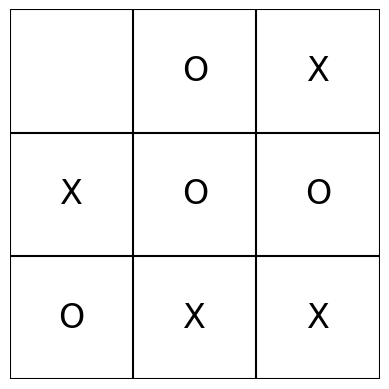

In [42]:
from IPython.display import clear_output
import time

def plot_board(cells, grid_size):
    fig, ax = plt.subplots()
    for i in range(grid_size + 1):
        ax.axhline(i - 0.5, color='black')
        ax.axvline(i - 0.5, color='black')
    for i, cell in enumerate(cells):
        r, c = divmod(i, grid_size)
        if cell == 0:
            label = ''
        elif cell == 1:
            label = 'O'
        else:
            label = 'X'
        ax.text(c, r, label, fontsize=24, ha='center', va='center')
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(-0.5, grid_size - 0.5)
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.axis('off')
    plt.show()

env = TicTacToeEnv(grid_size, win_length)
obs = env.reset()

plot_board(env.cells, grid_size)

debug = False

for step in range(n_cells):

    if debug:
        print(f"Step {step}, Turn: {'O' if env.turn == PLAYER_O else 'X'}")
        print(f"Observation for O: {obs[PLAYER_O]}")
        print(f"Observation for X: {obs[PLAYER_X]}")

        print("Inferring states...")

    qsO = agent_O.infer_states(obs)
    qsX = agent_X.infer_states(obs)

    if debug:
        print("Inferring policies...")

    agent_O.infer_policies()
    agent_X.infer_policies()

    if debug:
        print("Sampling actions...")

    chosen_action_O = agent_O.sample_action()
    
    if debug:
        print("O's policy posterior:", agent_O.q_pi)
        print("O's available policies:", agent_O.policies)
        print("O's sampled action:", chosen_action_O)
    
    chosen_action_X = agent_X.sample_action()
    
    if debug:
        print("X's policy posterior:", agent_X.q_pi)
        print("X's available policies:", agent_X.policies)
        print("X's sampled action:", chosen_action_X)

    # Should always choose a single action as we pass in a filtered policy list
    try:
        mark_action_id_O = np.where(chosen_action_O == 1)[0][0]
        print(f"O's mark action index: {mark_action_id_O}")
    except IndexError:
        raise ValueError("Null action sampled for O")
    try:
        mark_action_id_X = np.where(chosen_action_X == 1)[0][0]
        print(f"X's mark action index: {mark_action_id_X}")
    except IndexError:
        raise ValueError("Null action sampled for X")

    if debug:
        print("Executing action...")

    if env.turn == PLAYER_O:
        obs, reward, done = env.step(mark_action_id_O, agent=PLAYER_O)
    else:  # X's turn
        obs, reward, done = env.step(mark_action_id_X, agent=PLAYER_X)

    if not debug:
        clear_output(wait=True)
        plot_board(env.cells, grid_size)
    
    if grid_size == 3 and win_length == 3 and policy_len == 1:
        time.sleep(1) # Add delay to make it easier to track progress in fast game
    
    if done:
        if reward == 1:
            print('O wins!')
        elif reward == -1:
            print('X wins!')
        else:
            print('Draw!')
        break